In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Jun  4 21:33:25 2022

@author: ixn004
"""
#July 10, 2025


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

#from pyswarm import pso
from pyswarms.single.global_best import GlobalBestPSO #Date: Macrh 30,2024
from calculate_pZAP import run_bionetgen
from interpolation import spline
from ca_ODE import calcium, solve
from interpolation_exp_data import exp_idata


from data_slice import data_after_tstart
from ZAP_SYK_SSR_fit import calculate_residue
from calculate_SSR_gamma import gamma_PZAP
from calculate_SSR_zeta import zeta_PZAP    
from calculate_SSR_mixed import mixed_PZAP
import sys
      


In [2]:
#All 3 curves


K1=0.0026675475345120147
K2=0.1397364395199698

ZAP0=1131.0
SYK0=754.0

C1=10**5.5196370140314786
C2=10**0.523659992224274363
g=10**-2.077672213156433

#NK92 parameters
# a0_zeta=66
# a0_gamma=100

# #Equal ITAM
a0_zeta=20
a0_gamma=60


n = 3  # Number of bionetgen runs

dir_name="analysis"
   

In [3]:

tnew_gamma, PZAP_gamma, PSYK_gamma, N, dir_name_gamma = gamma_PZAP(n, K1, K2, a0_gamma, ZAP0, SYK0, dir_name)


k1 = 0.0026675475345120147
k2 = 0.1397364395199698
A0= 60
ZAP0= 1131.0
SYK0= 754.0
Running bionetgen simulations in directory: gamma_runs/analysis


In [4]:

tnew_zeta, PZAP_zeta, PSYK_zeta, N, dir_name_zeta = zeta_PZAP(n, K1, K2, a0_zeta, ZAP0, SYK0, dir_name)

k1 = 0.0026675475345120147
k2 = 0.1397364395199698
A0= 20
ZAP0= 1131.0
SYK0= 754.0
Running bionetgen simulations in directory: zeta_runs/analysis


In [5]:
#tnew_mixed, PZAP_mixed, PSYK_mixed, N, dir_name_mixed = mixed_PZAP(n, K1, K2, a0_mixed, ZAP0, SYK0, dir_name)

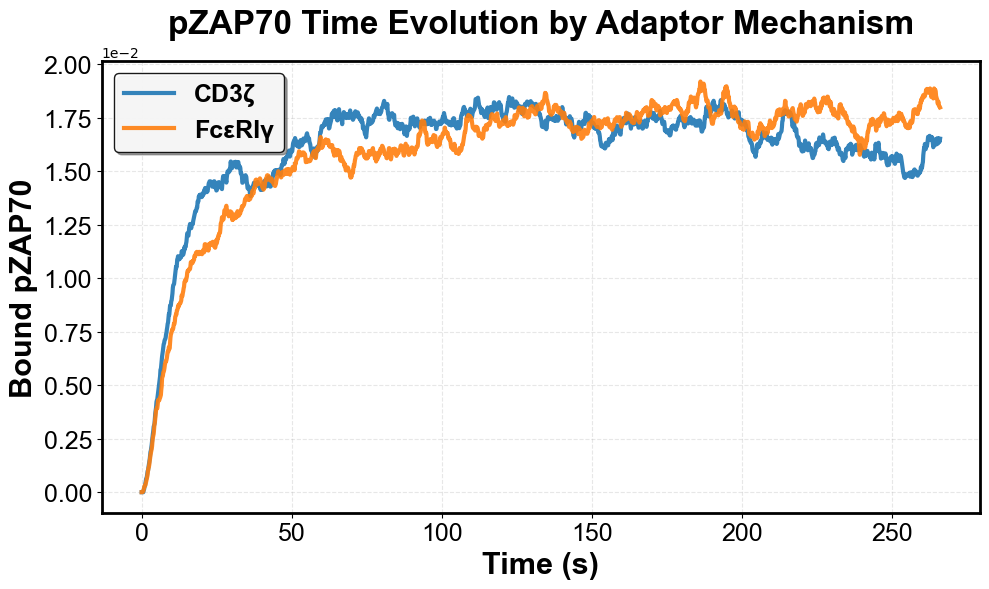

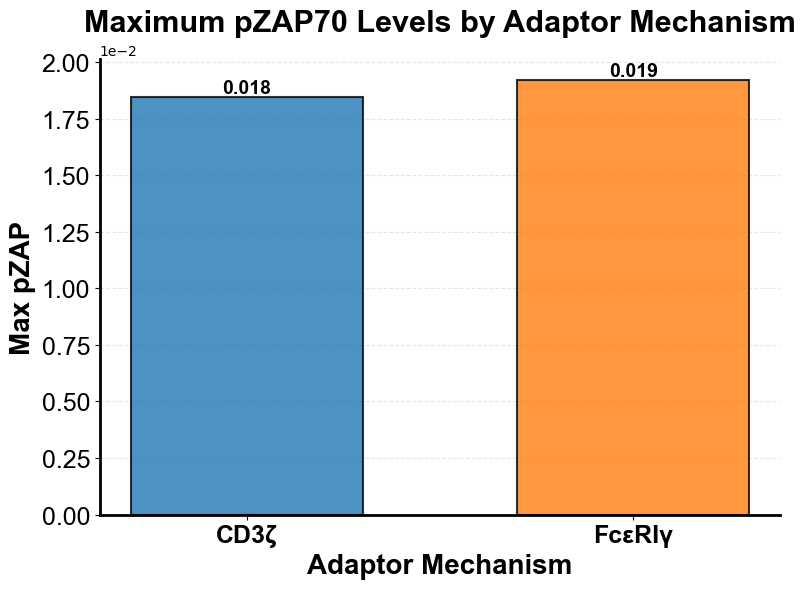

In [6]:
Vc=25.0 #pZAP molecules in the simulation box of size 25 um^3
z=602.0 #constant factor to convert from molecules/um3 to uM

# # Enhanced pZAP time series plot
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot with enhanced styling
# ax.plot(tnew_zeta, PSYK_zeta, label='CD3ζ', color='#1f77b4', linewidth=3, alpha=0.9)
# ax.plot(tnew_mixed, PSYK_mixed, label='Hetero', color='#87ceeb', linewidth=3, alpha=0.9)
# ax.plot(tnew_gamma, PSYK_gamma, label='FcεRIγ', color='#ff7f0e', linewidth=3, alpha=0.9)

# # Customize labels and title
# ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
# ax.set_ylabel('Total pSYK', fontfamily='Arial', fontsize=22, fontweight='bold')
# ax.set_title('pSYK Time Evolution by Adaptor Mechanism', 
#              fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# # Enhanced tick formatting
# ax.tick_params(axis='both', which='major', labelsize=18)
# plt.setp(ax.get_xticklabels(), fontfamily='Arial')
# plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# # Enhanced legend
# legend = ax.legend(prop={'family': 'Arial', 'size': 18, 'weight': 'bold'}, 
#                    frameon=True, fancybox=True, shadow=True, 
#                    framealpha=0.9, edgecolor='black')

# # Add grid
# ax.grid(True, alpha=0.3, linestyle='--')
# ax.set_axisbelow(True)

# # Set spine styling
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
#     spine.set_color('black')

# # Scientific notation if needed
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# plt.tight_layout()
# plt.show()


# Enhanced pZAP time series plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot with enhanced styling
ax.plot(tnew_zeta, PZAP_zeta, label='CD3ζ', color='#1f77b4', linewidth=3, alpha=0.9)
#ax.plot(tnew_mixed, PZAP_mixed, label='Hetero', color='#87ceeb', linewidth=3, alpha=0.9)
ax.plot(tnew_gamma, PZAP_gamma, label='FcεRIγ', color='#ff7f0e', linewidth=3, alpha=0.9)

# Customize labels and title
ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_ylabel('Bound pZAP70', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_title('pZAP70 Time Evolution by Adaptor Mechanism', 
             fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Enhanced legend
legend = ax.legend(prop={'family': 'Arial', 'size': 18, 'weight': 'bold'}, 
                   frameon=True, fancybox=True, shadow=True, 
                   framealpha=0.9, edgecolor='black')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set spine styling
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Scientific notation if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

# Create figure with better design
fig, ax = plt.subplots(figsize=(8, 6))

# Data and labels
mechanisms = ['CD3ζ',  'FcεRIγ']
max_values = [np.max(PZAP_zeta), np.max(PZAP_gamma)]
colors = ['#1f77b4',  '#ff7f0e']  # Professional color palette

# Create bars with enhanced styling
bars = ax.bar(mechanisms, max_values, 
              color=colors, 
              alpha=0.8,
              edgecolor='black',
              linewidth=1.5,
              width=0.6)

# Add value labels on top of bars
for bar, value in zip(bars, max_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.3f}',
            ha='center', va='bottom', 
            fontfamily='Arial', fontsize=14, fontweight='bold')

# Customize the plot
ax.set_ylabel('Max pZAP', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_xlabel('Adaptor Mechanism', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_title('Maximum pZAP70 Levels by Adaptor Mechanism', 
             fontfamily='Arial', fontsize=22, fontweight='bold', pad=20)

# Set tick parameters
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial', fontweight='bold')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_axisbelow(True)

# Set spine thickness and style
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Scientific notation for y-axis if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Adjust layout and show
plt.tight_layout()
plt.show()


